# Multiple linear regression
The online store owner wants to understand which factors influence the average customer check (target variable). To do this, a multiple linear regression model can be built to predict the average customer check based on several explanatory variables.

Data description:
- Target variable (`y`): Average check (USD).

Explanatory variables:
- `x₁`: Number of items in the cart.
- `x₂`: Average price per item (USD).
- `x₃`: Discount percentage applied to the order (%).
- `x₄`: Time spent on the website before placing the order (minutes).

Data:

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
num_items = [4, 8, 3, 7, 2, 6, 1, 5, 9, 2, 8, 4, 7, 3, 6, 2, 5, 9, 1, 4,
             7, 6, 3, 8, 2, 5, 4, 9, 7, 2, 6, 3, 8, 5, 1, 7, 9, 4, 6, 2]

avg_price = [150.8, 230.5, 175.2, 310.1, 200.0, 320.4, 120.5, 270.6, 450.2, 210.7,
             180.5, 350.1, 290.3, 410.5, 250.8, 280.7, 300.5, 490.1, 130.2, 260.5,
             340.8, 220.1, 170.5, 310.3, 180.6, 260.4, 300.9, 420.7, 290.5, 200.1,
             310.6, 150.5, 370.2, 280.5, 180.1, 400.7, 430.6, 270.5, 320.2, 150.6]

discount = [5.0, 10.5, 15.0, 8.5, 12.0, 20.0, 7.0, 14.0, 25.0, 6.5,
            9.0, 11.5, 22.0, 18.0, 10.0, 5.5, 16.0, 24.0, 13.0, 8.0,
            15.5, 17.0, 9.5, 19.0, 21.0, 7.5, 14.5, 25.0, 11.0, 10.0,
            20.5, 6.0, 13.5, 18.5, 8.5, 22.5, 24.5, 12.5, 14.0, 10.5]

time_spent = [25.0, 35.5, 28.0, 40.5, 22.0, 50.0, 18.5, 33.0, 48.5, 30.0,
              27.5, 38.0, 44.5, 39.0, 31.5, 29.0, 34.5, 49.0, 24.0, 32.0,
              37.5, 41.0, 26.0, 42.5, 23.5, 36.0, 30.5, 47.0, 29.5, 34.0,
              40.0, 28.5, 39.5, 43.0, 25.5, 45.5, 46.5, 30.0, 33.5, 27.0]

avg_order = [950, 1780, 1120, 2250, 870, 2000, 650, 1600, 3200, 1050,
             1250, 2500, 2100, 2800, 1800, 1650, 1900, 3400, 750, 1550,
             2300, 1850, 1150, 2400, 890, 1700, 1950, 3100, 2200, 1450,
             2000, 950, 2500, 1750, 1250, 2850, 3300, 1550, 2100, 950]

df = pd.DataFrame({'avg_order': avg_order,
                     'num_items': num_items,
                     'avg_price': avg_price,
                     'discount': discount,
                     'time_spent': time_spent
                     })

Stages of the task:

1. Form the matrix `X` of explanatory variables and the vector `y` of the target variable based on the `data` dataframe.

2. Split the data into training and test sets.

3. Train a linear regression model on the training data.

4. Make predictions with the model for the test data.

5. Evaluate the model’s quality using the **MAE** and **R²** metrics. What conclusion can be drawn?

6. Evaluate the model’s quality using the same metrics with cross-validation. What conclusion can be drawn?

7. Analyze the model coefficients for the explanatory variables and provide a meaningful interpretation of them in terms of their impact on the target variable.

8. Build a standardized regression model. Analyze its coefficients. Create a bar chart of the coefficients.

9. Draw your conclusion: which of the four factors considered has the greatest impact on the customer’s average check, and which has the least?

In [3]:
X = df[['num_items', 'avg_price', "discount", 'time_spent']]
y = df['avg_order']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# model training
model = LinearRegression()
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

# model evaluation
print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

MSE: 40452.745045380165
MAE: 166.5230550466379
R2: 0.9006827463746625


Модель демонструє високу точність - R2 - 0.90. Всередньому помилка у грошовій формі складає - 166 одиниць, але це не є критично.

In [9]:
model = LinearRegression()
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')

print("Cross-validation scores:", scores)
print("Mean MAE cross-validation score:", scores.mean())

Cross-validation scores: [-129.2032032  -166.2782     -156.15597443 -119.08749059 -147.72852745]
Mean MAE cross-validation score: -143.6906791344169


Модель показує сереню абсолютну помилку - 143 одиниці.



Проаналізуй коефіцієнти моделі при пояснюючих змінних, напиши їх змістовну інтерптетацію з точки зору впливу на пояснюючу змінну.

Побудуй стандартизовану регресійну модель. Проаналізуй її коефіцієнти. Побудуй стовпчасту діаграму коефіцієнтів.

У підсумку, який із чотирьох розглянутих факторів найбільше впливає на середній чек покупця? Який впливає найменше?

In [5]:
# get w_0
print("w_0:", model.intercept_)

# get coefficients
print("coefficients:", model.coef_)

w_0: -230.96373141456343
coefficients: [30.42849186  6.79303311 -9.73901441  6.64771757]


З кожним додатковим придбаним товаром середня вартість покупки зростає в середньому на 30 одиниць.

Якщо середня ціна придбаних товарів зростає на 1 одиницю, середня вартість покупки збільшується приблизно на 7 одиниць.

З кожним 1% збільшенням знижки на покупку середня вартість покупки зменшується на 10 одиниць.

З кожною додатковою хвилиною, проведеною на сайті, середня вартість покупки збільшується на 6.6 одиниць .

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('coefficients:', model.coef_)

coefficients: [ 75.76633371 631.42387493 -57.18704461  54.43617951]


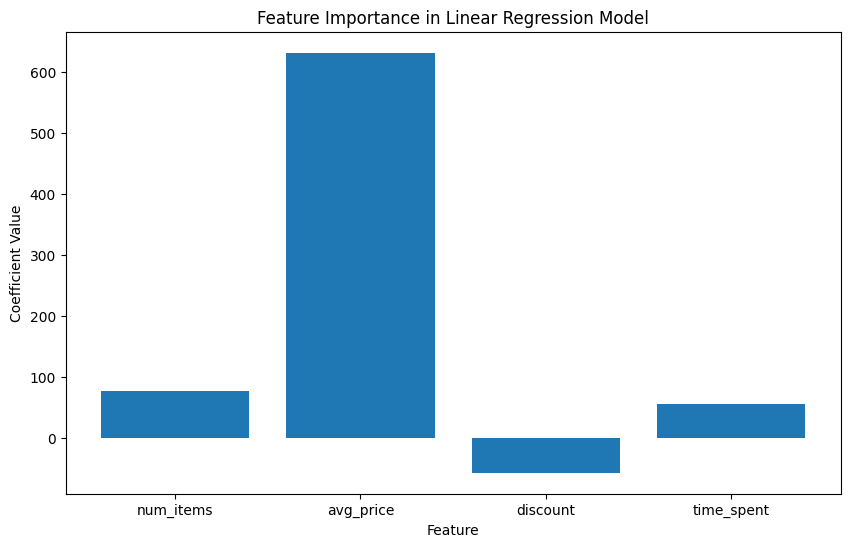

In [12]:
feature_importance = model.coef_


plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importance)), feature_importance,
        tick_label=['num_items', 'avg_price', "discount", 'time_spent'])
plt.title("Feature Importance in Linear Regression Model")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.show()

Отже, найбільший вплив на середню вартість покупки має середня ціна товарів у замовленні. Найменший вплив на середню вартість покупки мають розмір знижки та час, проведений на веб-сайті.